In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Covid_Data.csv")

In [5]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 591522 entries, 0 to 591521
Data columns (total 61 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   country                                     591522 non-null  object 
 1   date                                        591522 non-null  object 
 2   total_cases                                 579174 non-null  float64
 3   new_cases                                   574898 non-null  float64
 4   new_cases_smoothed                          573689 non-null  float64
 5   total_cases_per_million                     579174 non-null  float64
 6   new_cases_per_million                       574898 non-null  float64
 7   new_cases_smoothed_per_million              573689 non-null  float64
 8   total_deaths                                579174 non-null  float64
 9   new_deaths                                  576007 non-null  float64
 

,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,new_deaths_smoothed,total_deaths_per_million,...,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand,human_development_index
count,5.791740e+05,5.748980e+05,5.736890e+05,579174.000000,574898.000000,573689.000000,5.791740e+05,576007.000000,574795.000000,579174.000000,...,5.735000e+05,564193.000000,566522.000000,568848.000000,474397.000000,379785.000000,497681.000000,287559.000000,402869.000000,0.0
mean,1.495616e+07,9.460280e+03,9.480267e+03,138028.366617,88.701426,88.891886,1.601894e+05,90.470208,90.662862,960.625845,...,1.318604e+08,371.461117,31.153797,73.438377,27635.624601,13.690381,10.101276,62.385072,3.004089,NaN
std,7.636277e+07,1.111743e+05,9.494594e+04,179296.580994,927.874303,478.529423,7.947452e+05,762.193143,702.015464,1200.866624,...,6.695555e+08,1688.706134,9.666358,7.656049,26706.205558,20.818537,5.425728,31.283794,2.739255,NaN
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,...,5.130000e+02,0.136470,14.298000,18.817699,1051.259277,0.000000,1.500000,3.487560,0.150000,NaN
25%,1.018900e+04,0.000000e+00,0.000000e+00,3780.181225,0.000000,0.000000,8.500000e+01,0.000000,0.000000,51.347880,...,4.553740e+05,36.265862,22.243999,68.748703,6871.124512,0.413263,6.500000,28.407530,1.110000,NaN
50%,9.239350e+04,0.000000e+00,2.285714e+00,56868.240000,0.000000,0.352183,1.104000e+03,0.000000,0.000000,433.444180,...,6.035104e+06,92.084663,31.683001,74.695999,18477.214844,2.436315,8.600000,72.116234,2.410000,NaN
75%,1.153361e+06,3.300000e+01,1.368571e+02,215842.230000,3.606188,22.420507,1.393100e+04,0.000000,1.285714,1530.655200,...,2.971544e+07,237.470367,39.080002,78.768799,42829.199219,19.495604,12.100000,91.757347,3.970000,NaN
max,7.791355e+08,8.401906e+06,6.402033e+06,769806.800000,230762.550000,37463.746000,7.114321e+06,57167.000000,14820.714000,6603.976600,...,8.021407e+09,21344.242188,59.875000,85.746399,132569.531250,85.317673,31.400000,100.000000,21.990000,NaN


In [6]:
df = df.dropna(subset=['total_cases'])
df['date'] = pd.to_datetime(df['date'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 579174 entries, 3 to 591521
Data columns (total 61 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   country                                     579174 non-null  object        
 1   date                                        579174 non-null  datetime64[ns]
 2   total_cases                                 579174 non-null  float64       
 3   new_cases                                   574898 non-null  float64       
 4   new_cases_smoothed                          573689 non-null  float64       
 5   total_cases_per_million                     579174 non-null  float64       
 6   new_cases_per_million                       574898 non-null  float64       
 7   new_cases_smoothed_per_million              573689 non-null  float64       
 8   total_deaths                                579174 non-null  float64       
 9 

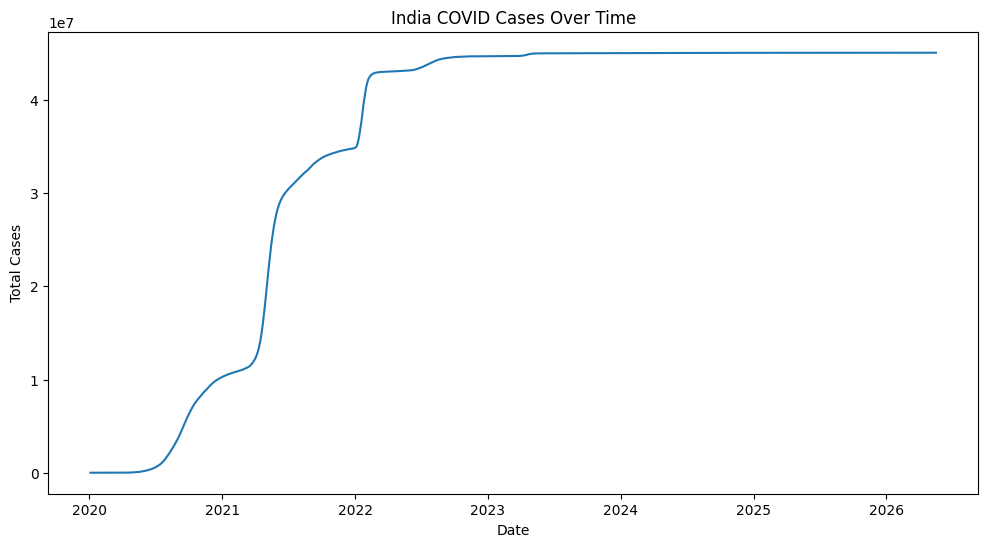

In [8]:
india = df[df['country'] == 'India']
plt.figure(figsize=(12,6))
plt.plot(india['date'], india['total_cases'])
plt.title("India COVID Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.show()


In [9]:
top = df.groupby('country')['total_cases'].max()

top = top.sort_values(ascending=False)

top.head(10)

country
World                                                  779135536.0
World excl. China                                      679753775.0
World excl. China and South Korea                      645181902.0
World excl. China, South Korea, Japan and Singapore    608372175.0
High-income countries                                  458049922.0
Asia                                                   302181905.0
Europe                                                 254960735.0
Upper-middle-income countries                          239832298.0
Asia excl. China                                       202800144.0
European Union (27)                                    186985838.0
Name: total_cases, dtype: float64

In [10]:
df.to_csv("cleaned_covid_data.csv", index=False)